In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ipythonx/mvtec-ad/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/in

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def build_gaussian_pyramid(image, levels=4):
    #Constructs a Gaussian Pyramid.
    pyramid = [image]
    temp_img = image.copy()
    
    for _ in range(levels - 1):
        temp_img = cv2.pyrDown(temp_img) # bluring,then downsampling
        pyramid.append(temp_img)
        
    return pyramid

In [4]:
def build_laplacian_pyramid(gaussian_pyramid):
     #Constructs a Laplacian Pyramid from a given Gaussian Pyramid.
    levels = len(gaussian_pyramid)
    laplacian_pyramid = []
    
    for i in range(levels - 1, 0, -1):
        gaussian_expanded = cv2.pyrUp(gaussian_pyramid[i]) # upsamling
        rows, cols = gaussian_pyramid[i - 1].shape[:2]
        gaussian_expanded = cv2.resize(gaussian_expanded, (cols, rows))
        
        laplacian = cv2.subtract(gaussian_pyramid[i - 1], gaussian_expanded)
        laplacian_pyramid.append(laplacian)

    laplacian_pyramid.reverse()
    
    return laplacian_pyramid

In [5]:
def build_pyramids(image, levels=4):
    g_pyr = build_gaussian_pyramid(image, levels)
    l_pyr = build_laplacian_pyramid(g_pyr)
    return g_pyr, l_pyr

In [7]:
def run_single_pipeline(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Error: Image not found")
        return

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

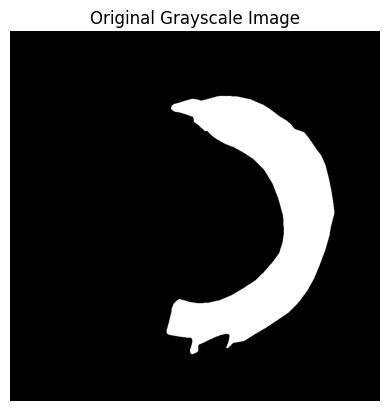

In [20]:
#/kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/broken_large/002.png
image_path = "/kaggle/input/datasets/ipythonx/mvtec-ad/bottle/ground_truth/broken_large/019_mask.png"

img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found!")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

In [21]:
g_pyr, l_pyr = build_pyramids(gray, levels=4)

print("Gaussian Pyramid Levels:", len(g_pyr))
print("Laplacian Pyramid Levels:", len(l_pyr))

Gaussian Pyramid Levels: 4
Laplacian Pyramid Levels: 3


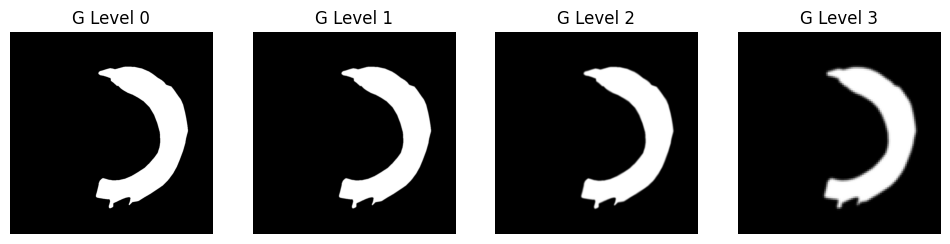

In [22]:
plt.figure(figsize=(12,4))

for i, level in enumerate(g_pyr):
    plt.subplot(1, len(g_pyr), i+1)
    plt.imshow(level, cmap="gray")
    plt.title(f"G Level {i}")
    plt.axis("off")

plt.show()

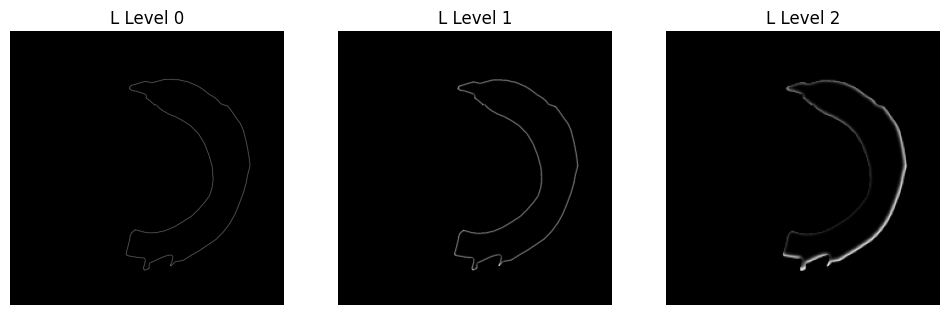

In [23]:
plt.figure(figsize=(12,4))

for i, level in enumerate(l_pyr):
    plt.subplot(1, len(l_pyr), i+1)
    plt.imshow(level, cmap="gray")
    plt.title(f"L Level {i}")
    plt.axis("off")

plt.show()